In [1]:
from micrograd.grad import Tensor
import numpy as np
from PIL import Image
from IPython.display import display

In [17]:
img = Image.open("example.png")

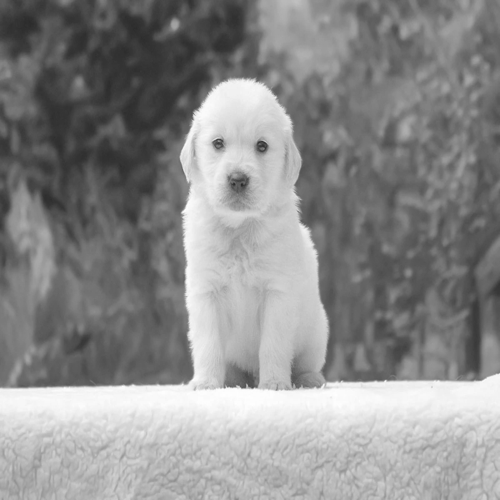

In [18]:
# preview of the image
img = img.resize((500,500))
img = img.convert('L')
img

In [6]:
img_array = np.array(img)
img_tensor = Tensor(img_array)
img_tensor.data.shape

(500, 500)

In [7]:
import random
kernel = np.random.uniform(-1,1,(10,10)) # (3x3) size of kernel and each RGB channel has different kernel


kernel
kernel = np.array([
    [-1,-1,-1],
    [-1, 8,-1],
    [-1,-1,-1]
])

kernel_tensor = Tensor(kernel)
kernel_tensor.data

array([[-1., -1., -1.],
       [-1.,  8., -1.],
       [-1., -1., -1.]])

In [ ]:
def conv2d(image,kernel):
    H,W = image.data.shape
    k = kernel.data.shape[0]
    
    out_h = H - k + 1
    out_w = W - k + 1
    
    rows = []
    
    for i in range(out_h):
        row_outputs = []
        
        for j in range(out_w):
            patch = image[i:i+k,j:j+k]
            temp = patch*kernel
            pixel = temp.sum()
            row_outputs.append(pixel)
        
        row_tensor = Tensor.stack(row_outputs,axis=0)
        rows.append(row_tensor)
        
        output = Tensor.stack(rows,axis=0)
    
    return output
out = conv2d(img_tensor, kernel_tensor)

# # # normalizing the output to have values between 0-255
img_data = out.data

img_data = img_data - img_data.min()
img_data = img_data / (img_data.max() + 1e-8)

img_data = (img_data * 255).astype(np.uint8)
img_after_conv = Image.fromarray(img_data)


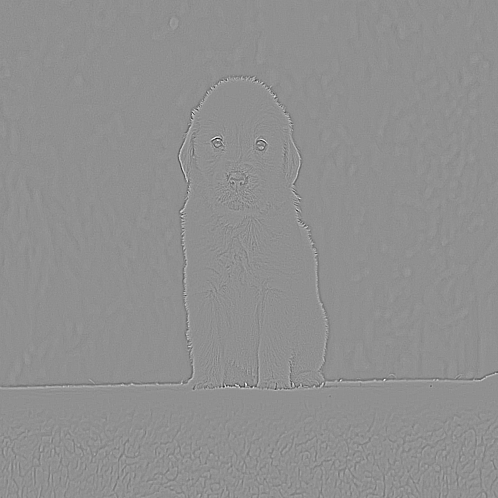

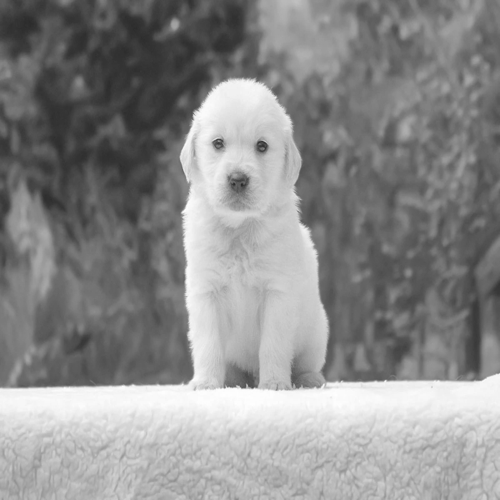

In [19]:
display(img_after_conv)
display(img)

In [20]:
out.backward()

In [21]:
kernel_tensor.grad

array([[34530468., 34537445., 34544636.],
       [34565577., 34572507., 34579657.],
       [34600781., 34607659., 34614764.]])

In [8]:
y.sum().backward()

In [10]:
x.grad

array([[0.33333333, 0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333, 0.33333333],
       [0.33333333, 0.33333333, 0.33333333, 0.33333333]])